# Three-Lens IL System: Two-Stage Calibration

This notebook calibrates the intermediate-lens (IL) system of a TEM from
pre-parsed DAC tables using an **analytic closed-form solver** for the two
imaging constraints ($A = m$, $B = 0$).

The fit uses a **two-stage workflow** where a sensitivity scan on $d_1^\text{img}$
between stages informs the bounds for the final fit.

## Notebook structure

| Section | Purpose |
|---------|---------|
| **Data** | Load 16-bit-normalised DAC tables for imaging and camera-length modes |
| **Physics** | Derivation of the analytic solver |
| **CAD priors** | Distance estimates from pixel measurements of the microscope column |
| **Analytic functions** | `phi2_exact`, `phi1_exact`, `model_at_data`, `make_residuals` |
| **Stage 1** | Preliminary fit — broad search over sign combinations and $\alpha$ seeds |
| **Sensitivity scan** | Sweep $d_1^\text{img}$ to find IL1-optimal value → set Stage 2 bounds |
| **Stage 2** | Final fit with tightened $d_1^\text{img}$ bounds, warm-started from Stage 1 |
| **Model evaluation** | Use the fitted parameters to predict the DAC curves at the measured operating points; no optimisation is performed here |
| **Forward solver** | `find_roots`, `predict_forward` — solve for DAC settings for new targets under an added current-sum constraint |
| **Physical diagnostics** | Focal lengths, turns ratios, current-sum invariant |
| **Appendix** | Raw DAC curve visualisation |

## Physical setup

Three intermediate lenses (IL1, IL2, IL3) sit between the objective and the
projector. The microscope operates in two modes that share the same IL optics
but differ in object-plane distance $d_1$.

| Mode | Target quantity | Relation |
|------|----------------|----------|
| **Imaging** | system magnification $M_\text{sys}$ | $M_\text{sys} = M_\text{obj}\times M_\text{IL}\times M_\text{proj}$ |
| **Camera length** | $\text{CL}$ [mm] | $\text{CL} = f_\text{obj}\times M_\text{IL}\times M_\text{proj}$ |

Scale factors $s_\text{img}$, $s_\text{cam}$ absorb the unknown
$M_\text{obj}$, $M_\text{proj}$, and $f_\text{obj}$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib widget
# ==== Distance-first compact data tables ====
# These are the same parsed 16-bit-normalized values previously derived from
# the raw hex service-menu tables.

mags_ref = np.array([30000.0, 40000.0, 50000.0, 60000.0, 80000.0, 100000.0,
                     120000.0, 150000.0, 200000.0, 250000.0, 300000.0,
                     400000.0, 500000.0, 600000.0], dtype=float)

cl_ref = np.array([80.0, 100.0, 120.0, 150.0, 200.0, 250.0, 300.0, 400.0,
                   500.0, 600.0, 800.0, 1000.0, 1200.0, 1500.0, 2000.0], dtype=float)

x_img = np.array([
    [0.621612548828125, 0.637542724609375, 0.65020751953125, 0.656494140625,
     0.659820556640625, 0.65625, 0.65557861328125, 0.6538238525390625,
     0.6514434814453125, 0.6510009765625, 0.6485595703125,
     0.64654541015625, 0.6449737548828125, 0.643798828125],
    [0.379364013671875, 0.379364013671875, 0.3929443359375, 0.4151611328125,
     0.443389892578125, 0.489349365234375, 0.489349365234375,
     0.5163726806640625, 0.5839080810546875, 0.5839080810546875,
     0.620208740234375, 0.67596435546875, 0.72369384765625,
     0.7647552490234375],
    [0.6062774658203125, 0.5423583984375, 0.5223236083984375,
     0.4974517822265625, 0.468048095703125, 0.4453887939453125,
     0.4238128662109375, 0.398040771484375, 0.360504150390625,
     0.3326873779296875, 0.2955322265625, 0.242523193359375,
     0.1968994140625, 0.1540679931640625],
], dtype=float)

x_cam = np.array([
    [0.3143310546875, 0.3218536376953125, 0.3208160400390625,
     0.325164794921875, 0.325164794921875, 0.3262176513671875,
     0.3267974853515625, 0.3269500732421875, 0.3263397216796875,
     0.3261871337890625, 0.3243865966796875, 0.3243865966796875,
     0.3234100341796875, 0.3220367431640625, 0.3204345703125],
    [0.6826324462890625, 0.6861724853515625, 0.690277099609375,
     0.6940460205078125, 0.70257568359375, 0.7133636474609375,
     0.7209320068359375, 0.7436981201171875, 0.7699737548828125,
     0.785888671875, 0.822265625, 0.8544921875, 0.8896484375,
     0.93798828125, 0.999755859375],
    [0.57269287109375, 0.5672454833984375, 0.5620269775390625,
     0.55426025390625, 0.5417327880859375, 0.529632568359375,
     0.5180511474609375, 0.4975128173828125, 0.4763641357421875,
     0.45703125, 0.42138671875, 0.390625, 0.358642578125,
     0.311767578125, 0.216796875],
], dtype=float)

print(f"Imaging:  {len(mags_ref)} points,  mag {mags_ref.min():.0f}..{mags_ref.max():.0f}")
print(f"Camera:   {len(cl_ref)} points,  CL {cl_ref.min():.0f}..{cl_ref.max():.0f} mm")
print("Compact data loaded. Proceed directly to distance fit (cell 4).")

Imaging:  14 points,  mag 30000..600000
Camera:   15 points,  CL 80..2000 mm
Compact data loaded. Proceed directly to distance fit (cell 4).


## Analytical Solver (Physics Explainer)

### Magnetic lens optics recap

The optical power (inverse focal length) of a magnetic round lens is

$$\phi \;=\; \frac{e}{8\,m_e\,U^*}\;\int_{-\infty}^{\infty} B_z^2(z)\,dz$$

where $U^* = U(1 + eU/2m_ec^2)$ is the relativistic accelerating potential.
Since $B_z \propto NI$, we get $\phi \propto (NI)^2$ with a proportionality
constant that depends only on geometry (bore, gap, pole pieces):

$$\phi_k \;=\; \underbrace{\alpha_{\mathrm{geom},k} N_k^2 I_{\max}^2}_{\alpha_k}\, x_k^2$$

The fit uses lumped constants $\alpha_k$. If lens geometries are similar,
$\alpha_k$ differences mainly reflect turns-ratio differences.

### Transfer-matrix model

Each thin lens and drift is

$$P(d)=\begin{pmatrix}1 & d\\0 & 1\end{pmatrix},\qquad
L(\phi)=\begin{pmatrix}1 & 0\\-\phi & 1\end{pmatrix}$$

and the IL block is

$$M=P(d_4)L(\phi_3)P(d_3)L(\phi_2)P(d_2)L(\phi_1)P(d_1).$$

Define $A=M_{00}$ and $B=M_{01}$.

For an imaging solution at target IL magnification $m$, we require:

- magnification constraint: $A=m$
- focus constraint: $B=0$

### Why the solver is analytic

Write

$$M = M_{\text{rest}}\,L(\phi_1)\,P(d_1),$$

with $M_{\text{rest}}=P(d_4)L(\phi_3)P(d_3)L(\phi_2)P(d_2)$.
Then top-row terms can be written as

$$A = a - b\phi_1,\qquad B = a d_1 + b(1-d_1\phi_1),$$

where $a,b$ depend only on $(\phi_2,\phi_3)$.
Substitute $\phi_1=(a-m)/b$ from $A=m$ into $B=0$:

$$a d_1 + b - d_1(a-m)=0 \Rightarrow b + d_1 m = 0.$$

So $\phi_1$ cancels out, and we first solve

$$M_{\text{rest}}[0,1] = -d_1 m.$$

This is linear in $\phi_2$ for fixed $\phi_3$, giving a closed form used in code
(`phi2_exact`). Then $\phi_1$ follows from $A=m$ in another closed form
(`phi1_exact`).

### Inverse fit strategy used here

At each measured operating point, we use the measured $x_3$ to set
$\phi_3=\alpha_3 x_3^2$, then compute:

1. $\phi_2^*=\texttt{phi2\_exact}(\phi_3,m,\mathbf d)$
2. $\phi_1^*=\texttt{phi1\_exact}(\phi_2^*,\phi_3,m,\mathbf d)$
3. $x_1^*=\sqrt{\phi_1^*/\alpha_1}$ and $x_2^*=\sqrt{\phi_2^*/\alpha_2}$

Residuals compare $(x_1^*,x_2^*)$ against measured $(x_1,x_2)$.
By construction, each valid point satisfies $A=m$ and $B=0$ exactly.

### Parameters fitted

Nine fit parameters are used:

- distances: $d_1^{img}, d_1^{cam}, d_2, d_4$
- lens constants: $\alpha_1,\alpha_2,\alpha_3$
- mode scales: $s_{img}, s_{cam}$

### Workflow intent

This notebook now runs in a distance-first way:

1. estimate distances and lens constants
2. report distance analytics first
3. evaluate model-vs-data with plots afterward

In [2]:
from scipy.optimize import least_squares, brentq

# ── CAD priors ────────────────────────────────────────────────────────
# Distance estimates from pixel measurements of the microscope column
# photograph (see measure_microscope_geometry notebook).
# All distances are normalised to d3 = 1 (the IL2→IL3 gap).

_px_mm = 200.0 / (624 - 528)              # pixel-to-mm calibration
D3_MM = (739 - 709) * _px_mm              # d3 in mm (reference length)

CAD = {
    'd2':     (709 - 672) * _px_mm / D3_MM,   # IL1→IL2
    'd4':     (764 - 739) * _px_mm / D3_MM,   # IL3→projector
    'd1_img': (672 - 666) * _px_mm / D3_MM,   # object→IL1 (imaging mode)
    'd1_cam': (672 - 576) * _px_mm / D3_MM,   # object→IL1 (camera-length mode)
}

# Prior weights: how strongly to pull fitted distances toward CAD values.
# d1_img prior is zeroed because the CAD estimate rests on only 6 pixels.
CAD_SIGMA = 0.20       # fractional uncertainty on each CAD distance
W_CAD     = 0.35       # weight for d2, d4 priors
W_CAD_D1I = 0.0        # weight for d1_img prior (disabled)

print(f"Reference gap  d3 = {D3_MM:.1f} mm")
print(f"\nCAD distance priors (normalised to d3 = 1):")
for k, v in CAD.items():
    print(f"  {k:7s} = {v:.3f}")


Reference gap  d3 = 62.5 mm

CAD distance priors (normalised to d3 = 1):
  d2      = 1.233
  d4      = 0.833
  d1_img  = 0.200
  d1_cam  = 3.200


## Analytic solver functions

These two functions implement the closed-form solutions derived in the physics
cell above. For given lens power $\phi_3$, target IL magnification $m$, and
distances $\mathbf{d} = (d_1, d_2, d_3, d_4)$:

- **`phi2_exact`** solves the combined $B = 0$, $A = m$ constraint for $\phi_2$
- **`phi1_exact`** solves $A = m$ for $\phi_1$ once $\phi_2$ and $\phi_3$ are known

In [3]:
# ── Closed-form solutions for phi2 and phi1 ──────────────────────────

BALANCE_EXPONENT = 0.35


def phi2_exact(phi3, m, d):
    """Solve the combined B=0, A=m constraint for phi2.

    Given phi3, target magnification m, and distances d = (d1, d2, d3, d4),
    returns the unique phi2 satisfying both imaging constraints.
    """
    d1, d2, d3, d4 = d
    num = d1 * m + (d2 + d3 + d4) - (d2 + d3) * d4 * phi3
    den = d2 * ((d3 + d4) - d3 * d4 * phi3)
    return num / den if abs(den) > 1e-30 else np.nan


def phi1_exact(phi2, phi3, m, d):
    """Solve A=m for phi1 with phi2, phi3 already known.

    Returns the lens power phi1 that gives the target magnification m.
    """
    d1, d2, d3, d4 = d
    A0 = 1.0 - (d3 + d4) * phi2 - d4 * phi3 + d3 * d4 * phi2 * phi3
    A1 = -(d2 + d3 + d4) + d2 * (d3 + d4) * phi2 + (d2 + d3) * d4 * phi3 - d2 * d3 * d4 * phi2 * phi3
    return (m - A0) / A1 if abs(A1) > 1e-30 else np.nan


def model_at_data(m_arr, x3_data, d, alpha):
    """Evaluate model-predicted DAC values at calibration points.

    For each operating point, fixes x3 to the measured value, then uses
    phi2_exact and phi1_exact to compute the predicted x1, x2.

    Returns (3, N) array of predicted [x1, x2, x3] DAC values.
    """
    out = np.full((3, len(m_arr)), np.nan)
    for j, m in enumerate(m_arr):
        p3 = alpha[2] * x3_data[j]**2
        p2 = phi2_exact(p3, m, d)
        if (not np.isfinite(p2)) or p2 <= 0:
            continue
        p1 = phi1_exact(p2, p3, m, d)
        if (not np.isfinite(p1)) or p1 <= 0:
            continue
        out[0, j] = np.sqrt(p1 / alpha[0])
        out[1, j] = np.sqrt(p2 / alpha[1])
        out[2, j] = x3_data[j]
    return out


def plateau_weights(values):
    """Downweight repeated DAC plateaus caused by table quantisation."""
    unique_vals, counts = np.unique(values, return_counts=True)
    count_map = dict(zip(unique_vals.tolist(), counts.tolist()))
    return np.array([count_map[val]**-0.5 for val in values], dtype=float)


# Balance the fit so flatter DAC curves are not overwhelmed by the higher-span ones.
img_span = np.ptp(x_img, axis=1)
cam_span = np.ptp(x_cam, axis=1)
img_weights = (np.median(img_span) / np.maximum(img_span, 1e-6))**BALANCE_EXPONENT
cam_weights = (np.median(cam_span) / np.maximum(cam_span, 1e-6))**BALANCE_EXPONENT

# Additional pointwise weights reduce the leverage of repeated DAC plateaus.
img_plateau_weights = np.vstack([plateau_weights(x_img[k]) for k in range(3)])
cam_plateau_weights = np.vstack([plateau_weights(x_cam[k]) for k in range(3)])
img_point_weights = img_weights[:, None] * img_plateau_weights
cam_point_weights = cam_weights[:, None] * cam_plateau_weights


def make_residuals(si, sc, w_cad_d1i=W_CAD_D1I):
    """Build the residual function for least_squares.

    Parameters
    ----------
    si, sc : +1 or -1
        Sign of the IL magnification in imaging / camera-length mode.
    w_cad_d1i : float
        Weight for the d1_img CAD prior (can be adjusted between stages).

    The 9-element parameter vector is:
        [d1_img, d1_cam, d2, d4, log(alpha1), log(alpha2), log(alpha3),
         log(s_img), log(s_cam)]
    """
    def fn(p):
        d1i, d1c, d2, d4 = p[:4]
        alpha = np.exp(p[4:7])
        s_i, s_c = np.exp(p[7]), np.exp(p[8])
        d_i, d_c = [d1i, d2, 1.0, d4], [d1c, d2, 1.0, d4]
        res = []
        for x_data, targets, d, s, sign, weights in [
            (x_img, mags_ref, d_i, s_i, si, img_point_weights),
            (x_cam, cl_ref,   d_c, s_c, sc, cam_point_weights),
        ]:
            for j in range(x_data.shape[1]):
                m = sign * s * targets[j]
                p3 = alpha[2] * x_data[2, j]**2
                p2s = phi2_exact(p3, m, d)
                if (not np.isfinite(p2s)) or p2s <= 0:
                    res.extend([1.0, 1.0])
                    continue
                p1s = phi1_exact(p2s, p3, m, d)
                if (not np.isfinite(p1s)) or p1s <= 0:
                    res.extend([1.0, 1.0])
                    continue
                res.append(weights[0, j] * (np.sqrt(p1s / alpha[0]) - x_data[0, j]))
                res.append(weights[1, j] * (np.sqrt(p2s / alpha[1]) - x_data[1, j]))
        # CAD distance priors
        for val, ref in [(d2, CAD['d2']), (d4, CAD['d4'])]:
            res.append(W_CAD * (val - ref) / (CAD_SIGMA * ref))
        res.append(w_cad_d1i * (d1i - CAD['d1_img']) / (CAD_SIGMA * CAD['d1_img']))
        res.append(W_CAD / 3 * (d1c - CAD['d1_cam']) / (CAD_SIGMA * CAD['d1_cam']))
        return np.array(res)
    return fn


# Parameter bounds (same for both stages)
lb = np.array([0.05, 0.10, 0.50, 0.30,
               np.log(0.01), np.log(0.01), np.log(0.01),
               np.log(1e-7), np.log(1e-7)])
ub = np.array([0.80, 7.0, 2.60, 1.80,
               np.log(1000), np.log(1000), np.log(1000),
               np.log(1.0), np.log(1.0)])

# Initial guess seeded from CAD distances
p0_base = [CAD['d1_img'], CAD['d1_cam'], CAD['d2'], CAD['d4'],
           0, 0, 0, np.log(1/3000), np.log(1/230)]

print("Analytic functions and residual builder defined.")
print(f"Parameter bounds: {len(lb)} parameters")
print(f"  Distances: d1_img in [{lb[0]:.2f}, {ub[0]:.2f}], d1_cam in [{lb[1]:.2f}, {ub[1]:.2f}]")
print(f"  d2 in [{lb[2]:.2f}, {ub[2]:.2f}], d4 in [{lb[3]:.2f}, {ub[3]:.2f}]")
print(f"Residual weighting exponent = {BALANCE_EXPONENT:.2f}")
print(f"Residual weighting  imaging = {img_weights.round(3)},  camera = {cam_weights.round(3)}")
print(f"Plateau weighting   imaging repeats = {np.unique(img_plateau_weights).round(3)},  camera repeats = {np.unique(cam_plateau_weights).round(3)}")

Analytic functions and residual builder defined.
Parameter bounds: 9 parameters
  Distances: d1_img in [0.05, 0.80], d1_cam in [0.10, 7.00]
  d2 in [0.50, 2.60], d4 in [0.30, 1.80]
Residual weighting exponent = 0.35
Residual weighting  imaging = [2.245 1.    0.946],  camera = [3.091 1.    0.96 ]
Plateau weighting   imaging repeats = [0.707 1.   ],  camera repeats = [0.707 1.   ]


## Stage 1: Preliminary fit

Run a broad search over all four sign combinations and multiple $\alpha$ seeds.
The `d1_img` CAD prior is **disabled** (`W_CAD_D1I = 0`) so the fit can explore
freely. The best result from this stage provides the parameters needed for the
sensitivity scan.

In [4]:
# ── Stage 1: broad search (d1_img prior disabled) ────────────────────

best, best_cost, best_signs = None, np.inf, (+1, +1)

for si, sc in [(+1, +1), (+1, -1), (-1, +1), (-1, -1)]:
    fn = make_residuals(si, sc, w_cad_d1i=0.0)
    for a1, a2, a3 in [(10, 10, 5), (3, 3.5, 2.5), (20, 20, 10), (5, 7, 4)]:
        p0 = list(p0_base)
        p0[4:7] = [np.log(a1), np.log(a2), np.log(a3)]
        try:
            res = least_squares(fn, p0, bounds=(lb, ub), method='trf',
                                max_nfev=20000, diff_step=0.001)
            if res.cost < best_cost:
                best_cost, best, best_signs = res.cost, res, (si, sc)
        except Exception:
            pass

si_best, sc_best = best_signs

# Refine the best preliminary result
fn_prelim = make_residuals(*best_signs, w_cad_d1i=0.0)
res = least_squares(fn_prelim, best.x, bounds=(lb, ub), method='trf',
                    max_nfev=100000, diff_step=1e-4,
                    ftol=1e-15, xtol=1e-15, gtol=1e-15)
if res.cost <= best_cost:
    best = res

# Extract preliminary parameters
d1i_prelim, d1c_prelim, d2_prelim, d4_prelim = best.x[:4]
alpha_prelim = np.exp(best.x[4:7])
s_img_prelim, s_cam_prelim = np.exp(best.x[7]), np.exp(best.x[8])
d_img_prelim = np.array([d1i_prelim, d2_prelim, 1.0, d4_prelim])
m_img_prelim = si_best * s_img_prelim * mags_ref

print(f"Stage 1 result  signs=({si_best:+d},{sc_best:+d})  cost={best.cost:.6f}")
print(f"  d1_img = {d1i_prelim:.4f}  ({d1i_prelim * D3_MM:.2f} mm)")
print(f"  d1_cam = {d1c_prelim:.4f}  ({d1c_prelim * D3_MM:.2f} mm)")
print(f"  d2     = {d2_prelim:.4f}  ({d2_prelim * D3_MM:.2f} mm)")
print(f"  d4     = {d4_prelim:.4f}  ({d4_prelim * D3_MM:.2f} mm)")
print(f"  alpha  = [{alpha_prelim[0]:.4f}, {alpha_prelim[1]:.4f}, {alpha_prelim[2]:.4f}]")

Stage 1 result  signs=(+1,+1)  cost=0.003456
  d1_img = 0.2648  (16.55 mm)
  d1_cam = 3.2027  (200.17 mm)
  d2     = 1.2337  (77.11 mm)
  d4     = 0.8333  (52.08 mm)
  alpha  = [11.2158, 17.1740, 6.6581]


## Sensitivity scan: $d_1^\text{img}$

Hold all Stage 1 parameters fixed except $d_1^\text{img}$ and sweep it across
its full range. The resulting RMSE curves for IL1 and IL2 show:

- Whether $d_1^\text{img}$ is the dominant source of IL1 mismatch
- The **IL1-optimal** $d_1^\text{img}$ value (IL1 RMSE minimum)
- How much the CAD estimate differs from the data-driven optimum

If the IL1-optimal value differs substantially from the preliminary fit, we
tighten the $d_1^\text{img}$ bounds for Stage 2.

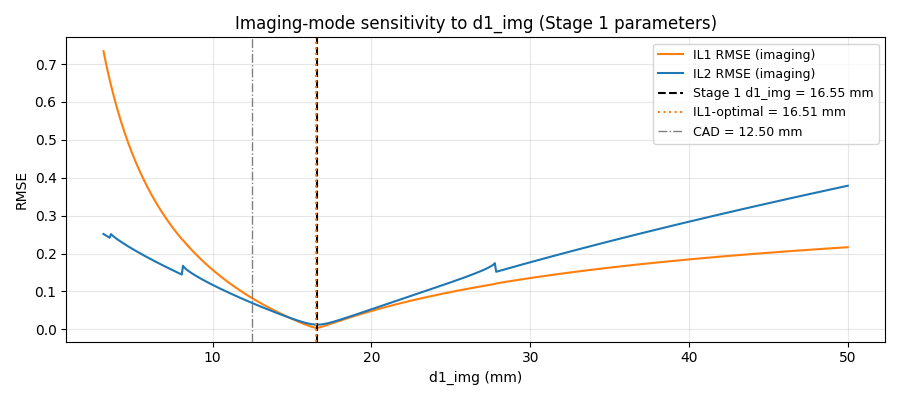

Stage 1  d1_img = 16.548 mm
IL1-optimal     = 16.507 mm  (shift -0.041 mm)
CAD estimate    = 12.500 mm

Stage 2 d1_img bounds: [0.211, 0.317]  = [13.21, 19.81] mm


In [5]:
# ── Sensitivity scan on d1_img using Stage 1 parameters ──────────────

d1_scan = np.linspace(0.05, 0.80, 600)
rmse_il1_scan, rmse_il2_scan = [], []

for d1_try in d1_scan:
    d_try = np.array([d1_try, d2_prelim, 1.0, d4_prelim])
    p = model_at_data(m_img_prelim, x_img[2], d_try, alpha_prelim)
    mi1 = np.isfinite(p[0])
    mi2 = np.isfinite(p[1])
    rmse_il1_scan.append(
        np.sqrt(np.mean((p[0, mi1] - x_img[0, mi1])**2)) if np.any(mi1) else np.nan)
    rmse_il2_scan.append(
        np.sqrt(np.mean((p[1, mi2] - x_img[1, mi2])**2)) if np.any(mi2) else np.nan)

rmse_il1_scan = np.array(rmse_il1_scan)
rmse_il2_scan = np.array(rmse_il2_scan)
best_d1_il1 = d1_scan[np.nanargmin(rmse_il1_scan)]

# ── Plot ──
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(d1_scan * D3_MM, rmse_il1_scan, color='C1', label='IL1 RMSE (imaging)')
ax.plot(d1_scan * D3_MM, rmse_il2_scan, color='C0', label='IL2 RMSE (imaging)')
ax.axvline(d1i_prelim * D3_MM, color='k', ls='--', lw=1.5,
           label=f'Stage 1 d1_img = {d1i_prelim * D3_MM:.2f} mm')
ax.axvline(best_d1_il1 * D3_MM, color='C1', ls=':', lw=1.5,
           label=f'IL1-optimal = {best_d1_il1 * D3_MM:.2f} mm')
ax.axvline(CAD['d1_img'] * D3_MM, color='gray', ls='-.', lw=1.0,
           label=f'CAD = {CAD["d1_img"] * D3_MM:.2f} mm')
ax.set_xlabel('d1_img (mm)')
ax.set_ylabel('RMSE')
ax.set_title('Imaging-mode sensitivity to d1_img (Stage 1 parameters)')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ── Decide d1_img bounds for Stage 2 ──
delta_mm = (best_d1_il1 - d1i_prelim) * D3_MM
print(f"Stage 1  d1_img = {d1i_prelim * D3_MM:.3f} mm")
print(f"IL1-optimal     = {best_d1_il1 * D3_MM:.3f} mm  (shift {delta_mm:+.3f} mm)")
print(f"CAD estimate    = {CAD['d1_img'] * D3_MM:.3f} mm")

# Set informed d1_img bounds: ±20% around the IL1-optimal value
d1_lo = max(0.05, best_d1_il1 * 0.80)
d1_hi = min(0.80, best_d1_il1 * 1.20)
print(f"\nStage 2 d1_img bounds: [{d1_lo:.3f}, {d1_hi:.3f}]  "
      f"= [{d1_lo * D3_MM:.2f}, {d1_hi * D3_MM:.2f}] mm")

## Stage 2: Final fit with informed $d_1^\text{img}$ bounds

Re-run the optimiser using:
- **Tightened $d_1^\text{img}$ bounds** from the sensitivity scan
- **Stage 1 result as the starting point** (warm start)
- Same sign combination that won in Stage 1

In [6]:
# ── Stage 2: re-fit with informed d1_img bounds ──────────────────────

lb2 = lb.copy()
ub2 = ub.copy()
lb2[0] = d1_lo
ub2[0] = d1_hi

# Warm-start from Stage 1, clamped to new bounds
p0_stage2 = np.clip(best.x, lb2, ub2)

fn_final = make_residuals(*best_signs, w_cad_d1i=0.0)
final = least_squares(fn_final, p0_stage2, bounds=(lb2, ub2), method='trf',
                      max_nfev=100000, diff_step=1e-4,
                      ftol=1e-15, xtol=1e-15, gtol=1e-15)

# ── Extract final fitted parameters ──────────────────────────────────

d1i_f, d1c_f, d2_f, d4_f = final.x[:4]
alpha_f = np.exp(final.x[4:7])
s_img_f, s_cam_f = np.exp(final.x[7]), np.exp(final.x[8])
d_img_f = np.array([d1i_f, d2_f, 1.0, d4_f])
d_cam_f = np.array([d1c_f, d2_f, 1.0, d4_f])
m_img = si_best * s_img_f * mags_ref
m_cam = sc_best * s_cam_f * cl_ref

print(f"Stage 2 result  cost={final.cost:.6f}  (Stage 1 was {best.cost:.6f})")
print(f"\nFitted distances (d3 = 1 = {D3_MM:.1f} mm):")
for nm, fit, cad in [('d1_img', d1i_f, CAD['d1_img']),
                     ('d1_cam', d1c_f, CAD['d1_cam']),
                     ('d2',     d2_f,  CAD['d2']),
                     ('d4',     d4_f,  CAD['d4'])]:
    print(f"  {nm:7s} = {fit:.4f}  ({fit * D3_MM:.2f} mm)  "
          f"CAD {cad:.3f} ({cad * D3_MM:.2f} mm)  "
          f"Δ = {(fit - cad) / (CAD_SIGMA * cad):+.1f}σ")

print(f"\nLens constants   α = [{alpha_f[0]:.4f}, {alpha_f[1]:.4f}, {alpha_f[2]:.4f}]")
print(f"Scale factors    s_img = {s_img_f:.4e}  →  M_obj·M_proj = {1/s_img_f:.1f}")
print(f"                 s_cam = {s_cam_f:.4e}  →  f_obj·M_proj = {1/s_cam_f:.1f}")

Stage 2 result  cost=0.003456  (Stage 1 was 0.003456)

Fitted distances (d3 = 1 = 62.5 mm):
  d1_img  = 0.2648  (16.55 mm)  CAD 0.200 (12.50 mm)  Δ = +1.6σ
  d1_cam  = 3.2027  (200.17 mm)  CAD 3.200 (200.00 mm)  Δ = +0.0σ
  d2      = 1.2337  (77.11 mm)  CAD 1.233 (77.08 mm)  Δ = +0.0σ
  d4      = 0.8333  (52.08 mm)  CAD 0.833 (52.08 mm)  Δ = -0.0σ

Lens constants   α = [11.2158, 17.1740, 6.6581]
Scale factors    s_img = 1.1153e-04  →  M_obj·M_proj = 8965.9
                 s_cam = 4.4038e-03  →  f_obj·M_proj = 227.1


## Model Evaluation

This section does not re-fit anything. It only evaluates the fitted model at the
measured operating points so we can inspect how the calibrated geometry and lens
constants reproduce the DAC tables.

To keep the presentation tighter while still being honest, each lens now gets:

- a full-scale panel on the native DAC range `[0, 1]`
- an inset zoom that shows the local mismatch clearly
- a residual panel below with `model - data`

This makes it easy to judge both the absolute operating range and the remaining
structured error without expanding the figure into separate full-scale and zoomed
grids.

In [7]:
# ── Evaluate model at all calibration points ─────────────────────────

pi_f = model_at_data(m_img, x_img[2], d_img_f, alpha_f)
pc_f = model_at_data(m_cam, x_cam[2], d_cam_f, alpha_f)

n_img_ok = int(np.sum(np.isfinite(pi_f[0])))
n_cam_ok = int(np.sum(np.isfinite(pc_f[0])))

# Per-lens RMSE
for mode, pred, meas, n_ok, label in [
    ('Imaging', pi_f, x_img, n_img_ok, mags_ref),
    ('Camera',  pc_f, x_cam, n_cam_ok, cl_ref),
]:
    print(f"\n{mode} mode: {n_ok}/{pred.shape[1]} points valid")
    for k, lens in enumerate(['IL1', 'IL2', 'IL3']):
        ok = np.isfinite(pred[k])
        if np.any(ok):
            rmse = np.sqrt(np.mean((pred[k, ok] - meas[k, ok])**2))
            print(f"  {lens} RMSE = {rmse:.5f}")


Imaging mode: 14/14 points valid
  IL1 RMSE = 0.00401
  IL2 RMSE = 0.01227
  IL3 RMSE = 0.00000

Camera mode: 15/15 points valid
  IL1 RMSE = 0.00146
  IL2 RMSE = 0.01604
  IL3 RMSE = 0.00000


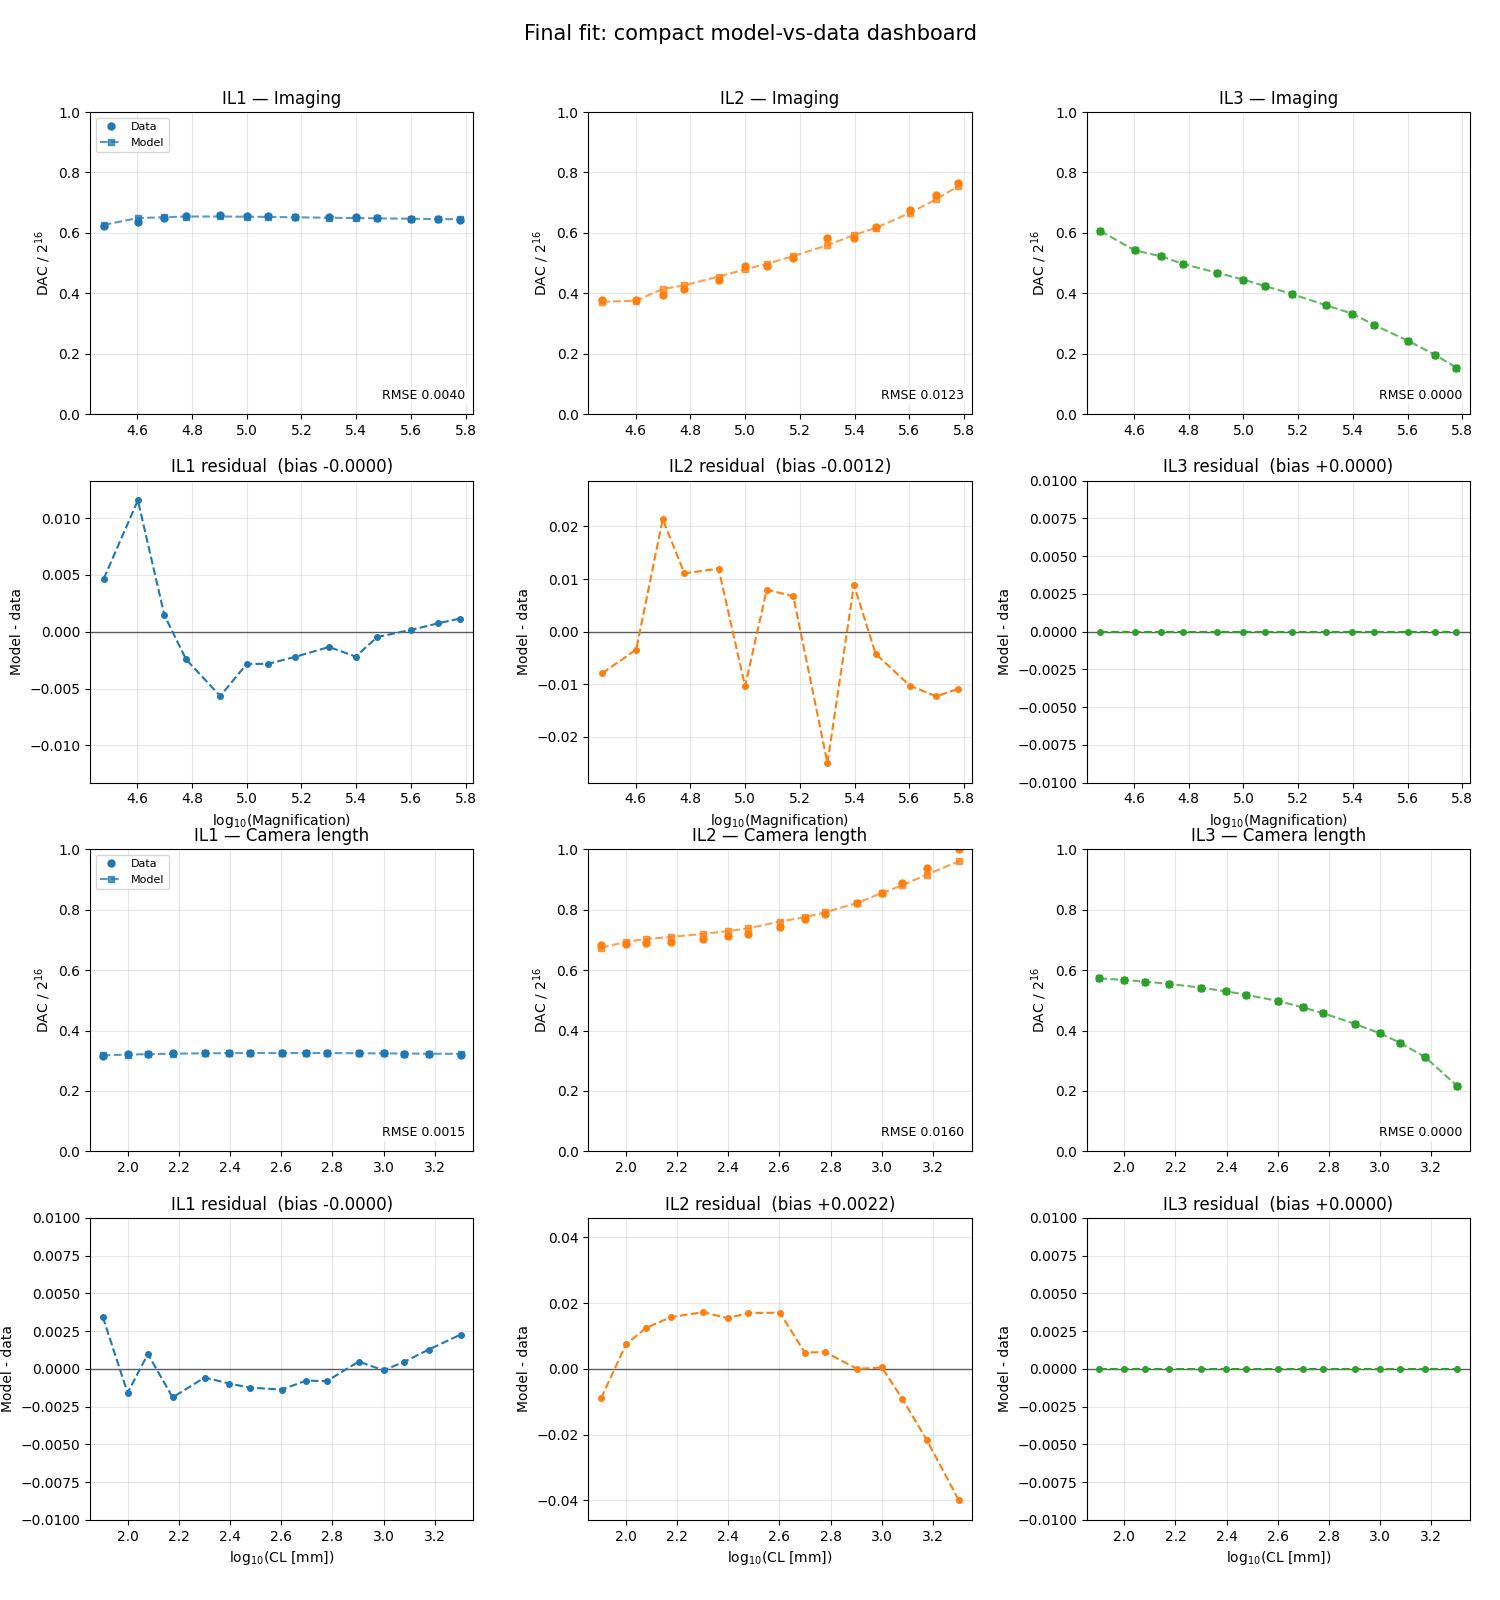

In [8]:
# ── Plot: compact model-vs-data dashboard (no zoom insets) ────────────

lens_names = ['IL1', 'IL2', 'IL3']
lens_colors = ['C0', 'C1', 'C2']

fig, axes = plt.subplots(4, 3, figsize=(15, 16))

log_mags = np.log10(mags_ref)
log_cl = np.log10(cl_ref)
img_xlim = (log_mags.min() - 0.05, log_mags.max() + 0.05)
cam_xlim = (log_cl.min() - 0.05, log_cl.max() + 0.05)


def residual_limits(residual, pad=0.15):
    values = residual[np.isfinite(residual)]
    if values.size == 0:
        return -0.05, 0.05
    bound = np.max(np.abs(values))
    bound = max(bound * (1 + pad), 0.01)
    return -bound, bound


def residual_stats(pred, data):
    ok = np.isfinite(pred)
    residual = np.full_like(pred, np.nan)
    residual[ok] = pred[ok] - data[ok]
    rmse = np.sqrt(np.mean(residual[ok]**2)) if np.any(ok) else np.nan
    bias = np.mean(residual[ok]) if np.any(ok) else np.nan
    return residual, rmse, bias


for k, (name, color) in enumerate(zip(lens_names, lens_colors)):
    residual_img, rmse_img, bias_img = residual_stats(pi_f[k], x_img[k])
    residual_cam, rmse_cam, bias_cam = residual_stats(pc_f[k], x_cam[k])

    ax = axes[0, k]
    ok = np.isfinite(pi_f[k])
    ax.plot(log_mags, x_img[k], 'o', color=color, ms=5, label='Data')
    ax.plot(log_mags[ok], pi_f[k, ok], 's--', color=color, ms=4, alpha=0.75, label='Model')
    ax.set_xlim(*img_xlim)
    ax.set_ylim(0.0, 1.0)
    ax.set_ylabel('DAC / $2^{16}$')
    ax.set_title(f'{name} — Imaging')
    ax.grid(True, alpha=0.3)
    ax.text(0.98, 0.04, f'RMSE {rmse_img:.4f}', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.8))
    if k == 0:
        ax.legend(fontsize=8, loc='upper left')

    ax = axes[1, k]
    ok = np.isfinite(pi_f[k])
    ax.axhline(0.0, color='k', lw=1.0, alpha=0.6)
    ax.plot(log_mags[ok], residual_img[ok], 'o--', color=color, ms=4)
    ylo, yhi = residual_limits(residual_img)
    ax.set_xlim(*img_xlim)
    ax.set_ylim(ylo, yhi)
    ax.set_ylabel('Model - data')
    ax.set_xlabel('log$_{10}$(Magnification)')
    ax.set_title(f'{name} residual  (bias {bias_img:+.4f})')
    ax.grid(True, alpha=0.3)

    ax = axes[2, k]
    ok = np.isfinite(pc_f[k])
    ax.plot(log_cl, x_cam[k], 'o', color=color, ms=5, label='Data')
    ax.plot(log_cl[ok], pc_f[k, ok], 's--', color=color, ms=4, alpha=0.75, label='Model')
    ax.set_xlim(*cam_xlim)
    ax.set_ylim(0.0, 1.0)
    ax.set_ylabel('DAC / $2^{16}$')
    ax.set_title(f'{name} — Camera length')
    ax.grid(True, alpha=0.3)
    ax.text(0.98, 0.04, f'RMSE {rmse_cam:.4f}', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.8))
    if k == 0:
        ax.legend(fontsize=8, loc='upper left')

    ax = axes[3, k]
    ok = np.isfinite(pc_f[k])
    ax.axhline(0.0, color='k', lw=1.0, alpha=0.6)
    ax.plot(log_cl[ok], residual_cam[ok], 'o--', color=color, ms=4)
    ylo, yhi = residual_limits(residual_cam)
    ax.set_xlim(*cam_xlim)
    ax.set_ylim(ylo, yhi)
    ax.set_ylabel('Model - data')
    ax.set_xlabel('log$_{10}$(CL [mm])')
    ax.set_title(f'{name} residual  (bias {bias_cam:+.4f})')
    ax.grid(True, alpha=0.3)

fig.suptitle('Final fit: compact model-vs-data dashboard', fontsize=15, y=0.985)
fig.subplots_adjust(top=0.93, bottom=0.05, left=0.06, right=0.98, hspace=0.22, wspace=0.30)
plt.show()


## Forward solver (optional)

This is the section that does a genuine forward solve for **new target
settings**.

Given a target magnification and a total-current constraint $x_1 + x_2 + x_3 = r$,
these functions find the DAC settings that satisfy $A = m$ and $B = 0$:

- **`find_roots`** — scans an $x_3$ grid, solves $\phi_2$ and $\phi_1$ analytically
  at each point, then uses Brent's method to find exact zero-crossings of the
  rotation residual $x_1 + x_2 + x_3 - r$
- **`predict_forward`** — calls `find_roots` for each target, picking the
  branch closest to the previous solution for continuity

Unlike the model-evaluation section above, this part is solving for previously
unknown DAC settings rather than simply plotting predictions at measured data
points.

## Physical diagnostics

Derived physical quantities from the final fit: focal lengths, implied
turns ratios, and the current-sum invariant $\Sigma x_k$.

In [9]:
# ── Physical constants ─────────────────────────────────────────────────

M_PROJ = -100.0          # projector magnification (assumed)
U_ACCEL = 200e3           # accelerating voltage [V]

# ── Derived quantities ────────────────────────────────────────────────

f_obj_mm = 1.0 / (abs(M_PROJ) * s_cam_f)
gamma = np.sqrt(alpha_f / alpha_f[0])   # relative turns ratios

print(f"f_obj = {f_obj_mm:.3f} mm  (from s_cam and M_proj)")
print(f"Implied turns ratios  γ = [{gamma[0]:.4f}, {gamma[1]:.4f}, {gamma[2]:.4f}]")
print(f"  If N_1 = 1000:  N = [{1000*gamma[0]:.0f}, {1000*gamma[1]:.0f}, {1000*gamma[2]:.0f}]")

# ── Real distances (mm) ──────────────────────────────────────────────

print(f"\nDistances (mm):")
print(f"  d1_img = {d1i_f * D3_MM:.1f}   d1_cam = {d1c_f * D3_MM:.1f}")
print(f"  d2     = {d2_f * D3_MM:.1f}   d3     = {D3_MM:.1f}")
print(f"  d4     = {d4_f * D3_MM:.1f}")

# ── Focal lengths at every operating point ───────────────────────────

print(f"\nFocal lengths  f = d3 / (α·x²)  [mm]")
print(f"\n{'Mag':>8s}  {'f1':>8s}  {'f2':>8s}  {'f3':>8s}  {'φ1':>6s}  {'φ2':>6s}  {'φ3':>6s}")
print("-" * 58)
for j in range(len(mags_ref)):
    phi = alpha_f * x_img[:, j]**2
    f = D3_MM / phi
    print(f"{mags_ref[j]:>8.0f}  {f[0]:>8.2f}  {f[1]:>8.2f}  {f[2]:>8.2f}  "
          f"{phi[0]:>6.2f}  {phi[1]:>6.2f}  {phi[2]:>6.2f}")

print(f"\n{'CL (mm)':>8s}  {'f1':>8s}  {'f2':>8s}  {'f3':>8s}  {'φ1':>6s}  {'φ2':>6s}  {'φ3':>6s}")
print("-" * 58)
for j in range(len(cl_ref)):
    phi = alpha_f * x_cam[:, j]**2
    f = D3_MM / phi
    print(f"{cl_ref[j]:>8.0f}  {f[0]:>8.2f}  {f[1]:>8.2f}  {f[2]:>8.2f}  "
          f"{phi[0]:>6.2f}  {phi[1]:>6.2f}  {phi[2]:>6.2f}")

# ── Current-sum invariant ────────────────────────────────────────────

r_img_vals = x_img.sum(axis=0)
r_cam_vals = x_cam.sum(axis=0)
print(f"\nΣxk invariant  (lower CV% = more constant):")
print(f"  Imaging: {np.mean(r_img_vals):.4f} ± {np.std(r_img_vals):.4f}  "
      f"CV = {np.std(r_img_vals)/np.mean(r_img_vals)*100:.2f}%")
print(f"  Camera:  {np.mean(r_cam_vals):.4f} ± {np.std(r_cam_vals):.4f}  "
      f"CV = {np.std(r_cam_vals)/np.mean(r_cam_vals)*100:.2f}%")

f_obj = 2.271 mm  (from s_cam and M_proj)
Implied turns ratios  γ = [1.0000, 1.2374, 0.7705]
  If N_1 = 1000:  N = [1000, 1237, 770]

Distances (mm):
  d1_img = 16.5   d1_cam = 200.2
  d2     = 77.1   d3     = 62.5
  d4     = 52.1

Focal lengths  f = d3 / (α·x²)  [mm]

     Mag        f1        f2        f3      φ1      φ2      φ3
----------------------------------------------------------
   30000     14.42     25.29     25.54    4.33    2.47    2.45
   40000     13.71     25.29     31.91    4.56    2.47    1.96
   50000     13.18     23.57     34.41    4.74    2.65    1.82
   60000     12.93     21.11     37.93    4.83    2.96    1.65
   80000     12.80     18.51     42.85    4.88    3.38    1.46
  100000     12.94     15.20     47.32    4.83    4.11    1.32
  120000     12.97     15.20     52.26    4.82    4.11    1.20
  150000     13.04     13.65     59.25    4.79    4.58    1.05
  200000     13.13     10.67     72.23    4.76    5.86    0.87
  250000     13.15     10.67     84.81   

## Appendix: raw DAC curves

Visualise the raw 16-bit-normalised DAC values for all three IL lenses as a
function of magnification (imaging mode) and camera length.

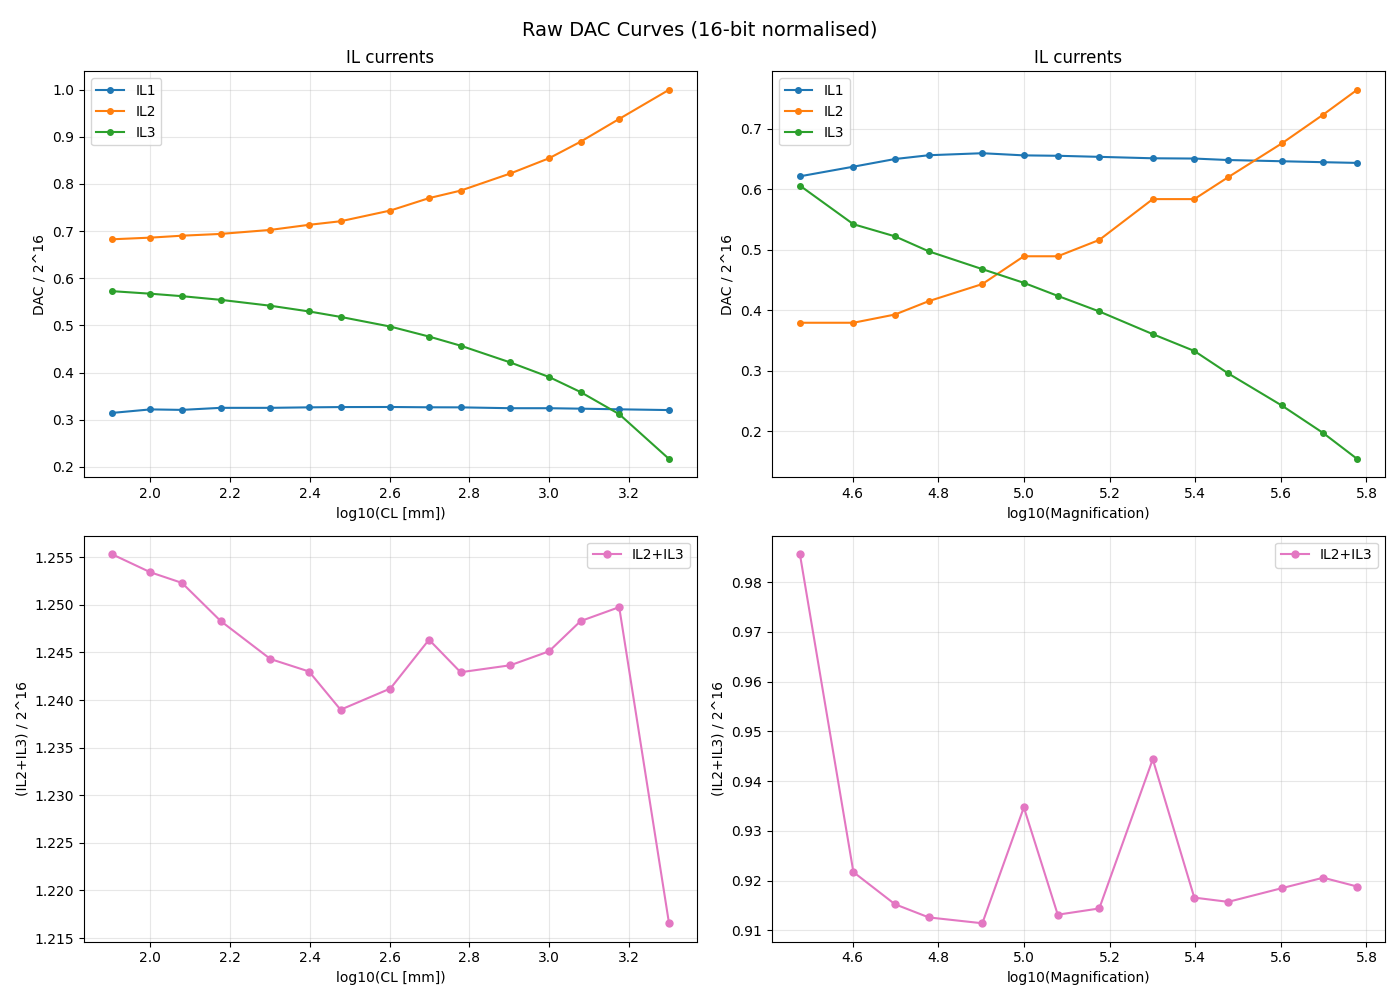

In [10]:
# ── Appendix: raw DAC curve visualisation ────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col, (primary, x, xlabel) in enumerate([
    (cl_ref, x_cam, "log10(CL [mm])"),
    (mags_ref, x_img, "log10(Magnification)"),
]):
    log_p = np.log10(primary)
    ax = axes[0, col]
    for i, (nm, c) in enumerate(zip(["IL1", "IL2", "IL3"], ["C0", "C1", "C2"])):
        ax.plot(log_p, x[i], "o-", label=nm, color=c, ms=4)
    ax.set_ylabel("DAC / 2^16")
    ax.set_xlabel(xlabel)
    ax.set_title("IL currents")
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1, col]
    ax.plot(log_p, x[1] + x[2], "o-", color="C6", ms=5, label="IL2+IL3")
    ax.set_ylabel("(IL2+IL3) / 2^16")
    ax.set_xlabel(xlabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle("Raw DAC Curves (16-bit normalised)", fontsize=14)
fig.tight_layout()
plt.show()

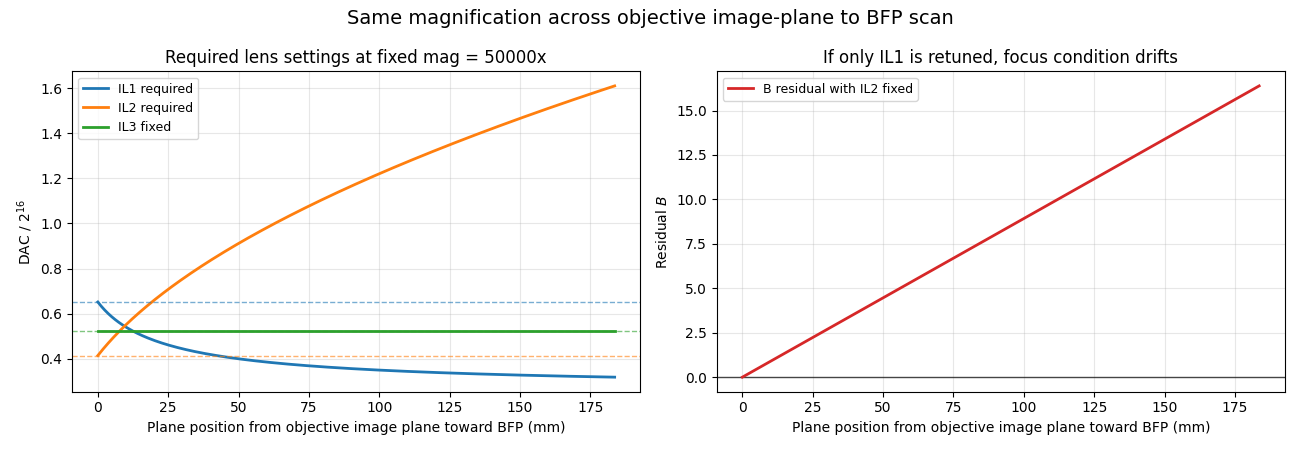

Target imaging magnification: 50000x
Reference IL3 setting held fixed: x3 = 0.52232
Image-plane to BFP scan: 0.00 mm to 183.622 mm
d1 endpoints: image plane = 16.548 mm, BFP = 200.170 mm

IL1 required range: 0.31844 -> 0.65166   (Δ = 0.33322)
IL2 required range: 0.41431 -> 1.60972   (Δ = 1.19540)
IL3 required range: 0.52232 -> 0.52232   (held fixed)
Max |B| if only IL1 is retuned and IL2 is held fixed: 16.38402


In [11]:
# ── Fixed-magnification depth scan from objective image plane to BFP ──

mag_target = 50000.0
ref_idx = int(np.argmin(np.abs(mags_ref - mag_target)))
mag_target = float(mags_ref[ref_idx])
m_target = si_best * s_img_f * mag_target
x3_fixed = float(x_img[2, ref_idx])
phi3_fixed = alpha_f[2] * x3_fixed**2

d1_img_mm = d1i_f * D3_MM
d1_bfp_mm = d1c_f * D3_MM
scan_span_mm = d1_bfp_mm - d1_img_mm
if scan_span_mm <= 0:
    raise RuntimeError('Expected d1_cam to be larger than d1_img for the image-plane to BFP scan.')

# Use the fitted image-plane and BFP distances directly.
depth_image_to_bfp_mm = np.linspace(0.0, scan_span_mm, 300)
d1_scan_depth = d1i_f + depth_image_to_bfp_mm / D3_MM


def ab_from_phis(phi1, phi2, phi3, d):
    d1, d2, d3, d4 = d
    P = lambda drift: np.array([[1.0, drift], [0.0, 1.0]])
    L = lambda phi: np.array([[1.0, 0.0], [-phi, 1.0]])
    M = P(d4) @ L(phi3) @ P(d3) @ L(phi2) @ P(d2) @ L(phi1) @ P(d1)
    return M[0, 0], M[0, 1]


x_required = np.full((3, depth_image_to_bfp_mm.size), np.nan)
x_il1_only = np.full(depth_image_to_bfp_mm.size, np.nan)
B_il1_only = np.full(depth_image_to_bfp_mm.size, np.nan)
A_il1_only = np.full(depth_image_to_bfp_mm.size, np.nan)

phi2_ref = phi2_exact(phi3_fixed, m_target, d_img_f)
phi1_ref = phi1_exact(phi2_ref, phi3_fixed, m_target, d_img_f)
x1_ref = np.sqrt(phi1_ref / alpha_f[0])
x2_ref = np.sqrt(phi2_ref / alpha_f[1])

for idx, d1_now in enumerate(d1_scan_depth):
    d_now = np.array([d1_now, d2_f, 1.0, d4_f])

    phi2_now = phi2_exact(phi3_fixed, m_target, d_now)
    phi1_now = phi1_exact(phi2_now, phi3_fixed, m_target, d_now)
    if np.isfinite(phi1_now) and np.isfinite(phi2_now) and phi1_now > 0 and phi2_now > 0:
        x_required[0, idx] = np.sqrt(phi1_now / alpha_f[0])
        x_required[1, idx] = np.sqrt(phi2_now / alpha_f[1])
        x_required[2, idx] = x3_fixed

    # IL1-only attempt: keep IL2 and IL3 fixed at the image-plane solution,
    # then retune IL1 just enough to preserve A = m.
    phi1_only = phi1_exact(phi2_ref, phi3_fixed, m_target, d_now)
    if np.isfinite(phi1_only) and phi1_only > 0:
        x_il1_only[idx] = np.sqrt(phi1_only / alpha_f[0])
        A_il1_only[idx], B_il1_only[idx] = ab_from_phis(phi1_only, phi2_ref, phi3_fixed, d_now)


valid = np.isfinite(x_required[0]) & np.isfinite(x_required[1])
if not np.any(valid):
    raise RuntimeError('No valid fixed-magnification depth-scan solutions were found.')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(depth_image_to_bfp_mm[valid], x_required[0, valid], color='C0', lw=2, label='IL1 required')
ax.plot(depth_image_to_bfp_mm[valid], x_required[1, valid], color='C1', lw=2, label='IL2 required')
ax.plot(depth_image_to_bfp_mm[valid], x_required[2, valid], color='C2', lw=2, label='IL3 fixed')
ax.axhline(x1_ref, color='C0', ls='--', lw=1, alpha=0.6)
ax.axhline(x2_ref, color='C1', ls='--', lw=1, alpha=0.6)
ax.axhline(x3_fixed, color='C2', ls='--', lw=1, alpha=0.6)
ax.set_xlabel('Plane position from objective image plane toward BFP (mm)')
ax.set_ylabel('DAC / $2^{16}$')
ax.set_title(f'Required lens settings at fixed mag = {mag_target:.0f}x')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)

ax = axes[1]
ax.axhline(0.0, color='k', lw=1.0, alpha=0.7)
ax.plot(depth_image_to_bfp_mm[np.isfinite(B_il1_only)], B_il1_only[np.isfinite(B_il1_only)],
        color='C3', lw=2, label='B residual with IL2 fixed')
ax.set_xlabel('Plane position from objective image plane toward BFP (mm)')
ax.set_ylabel('Residual $B$')
ax.set_title('If only IL1 is retuned, focus condition drifts')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)

fig.suptitle('Same magnification across objective image-plane to BFP scan', fontsize=14)
fig.tight_layout()
plt.show()

il1_span = (np.nanmin(x_required[0]), np.nanmax(x_required[0]))
il2_span = (np.nanmin(x_required[1]), np.nanmax(x_required[1]))
il3_span = (np.nanmin(x_required[2]), np.nanmax(x_required[2]))

print(f'Target imaging magnification: {mag_target:.0f}x')
print(f'Reference IL3 setting held fixed: x3 = {x3_fixed:.5f}')
print(f'Image-plane to BFP scan: 0.00 mm to {scan_span_mm:.3f} mm')
print(f'd1 endpoints: image plane = {d1_img_mm:.3f} mm, BFP = {d1_bfp_mm:.3f} mm')
print('')
print(f'IL1 required range: {il1_span[0]:.5f} -> {il1_span[1]:.5f}   (Δ = {il1_span[1] - il1_span[0]:.5f})')
print(f'IL2 required range: {il2_span[0]:.5f} -> {il2_span[1]:.5f}   (Δ = {il2_span[1] - il2_span[0]:.5f})')
print(f'IL3 required range: {il3_span[0]:.5f} -> {il3_span[1]:.5f}   (held fixed)')
print(f'Max |B| if only IL1 is retuned and IL2 is held fixed: {np.nanmax(np.abs(B_il1_only)):.5f}')

## Fixed-magnification depth scan

This exploratory section now uses the user-specified physical interpretation of the
fitted distances:

- `d1_img` is taken as the objective image-plane setting
- `d1_cam` is taken as the setting that images the objective back focal plane

So the scan range is not inferred from `f_obj`. It is taken directly from the fit as

$$d_1 \in [d_1^{img},\ d_1^{cam}]$$

and the plots below ask: at fixed imaging magnification, what IL settings are needed
as the selected plane moves from the objective image plane to the objective BFP?

In this relay model, IL3 is held fixed while IL1 and IL2 are re-solved from the
constraints $A = m$ and $B = 0$. The second panel shows what happens if IL2 is held
fixed and only IL1 is allowed to move.

## Export fitted geometry for microscope.toml

Convert the fitted normalised distances to absolute z-positions (metres) consistent
with the column geometry used in `microscope_design_curves.ipynb` and
`microscope.toml`.

The constraint study fits distances normalised to $d_3 = 1$ (the IL2→IL3 gap).
To recover physical distances we multiply by `D3_MM` (mm) then convert to metres.

The upstream geometry (source → Obj_post) is taken from the existing toml and
`microscope_design_curves` notebook, which are consistent with each other up to
the objective post-field lens. The IL geometry downstream of Obj_post is then
reconstructed from the fitted distances.

**Note:** `d1_img` is the object→IL1 distance in imaging mode. This includes
both the Obj_post→objective-image drift and the objective-image→IL1 drift.
The design curves notebook parameterises this as `d_ObjPost_to_IL1`, so:

$$z_\text{IL1} = z_\text{ObjPost} + d_1^\text{img} \times D_3 \times 10^{-3}$$

In [15]:
# ── Export: convert fitted distances to toml z-positions ──────────────
#
# Upstream geometry (source → Obj_post) is fixed and taken from the
# existing microscope.toml / design_curves notebook.

# Upstream z-positions (metres) — these are not fitted, just context.
Z_SOURCE         = 0.0
Z_CL1            = 0.2000
Z_CL3            = 0.2400
Z_APERTURE       = 0.2500
Z_CMINI          = 0.3000
Z_OBJ_PREFIELD   = 0.3200
Z_SAMPLE         = 0.3250   # Obj_prefield + 5 mm
Z_OBJ_POST       = 0.3273   # Sample + 2.3 mm

# Fitted physical distances (metres)
d1_img_m = d1i_f * D3_MM * 1e-3   # object-plane → IL1 (imaging mode)
d1_cam_m = d1c_f * D3_MM * 1e-3   # BFP → IL1 (camera-length mode)
d2_m     = d2_f  * D3_MM * 1e-3   # IL1 → IL2
d3_m     = D3_MM * 1e-3           # IL2 → IL3 (reference gap)
d4_m     = d4_f  * D3_MM * 1e-3   # IL3 → PL1

# Derive z-positions
z_il1 = Z_OBJ_POST + d1_img_m
z_il2 = z_il1 + d2_m
z_il3 = z_il2 + d3_m
z_pl1 = z_il3 + d4_m

print("=" * 64)
print("TOML z-positions for IL lenses (copy into microscope.toml)")
print("=" * 64)
print(f"""
[lenses.Obj_post]
z_m = {Z_OBJ_POST:.16f}

[lenses.IL1]
z_m = {z_il1:.16f}

[lenses.IL2]
z_m = {z_il2:.16f}

[lenses.IL3]
z_m = {z_il3:.16f}

[lenses.PL1]
z_m = {z_pl1:.16f}
""")

print("=" * 64)
print("Fitted distances for design_curves sys_config (metres)")
print("=" * 64)
print(f"  d_ObjPost_to_IL1:  {d1_img_m:.6e}  ({d1_img_m*1e3:.3f} mm)")
print(f"  d_IL1_to_IL2:      {d2_m:.6e}  ({d2_m*1e3:.3f} mm)")
print(f"  d_IL2_to_IL3:      {d3_m:.6e}  ({d3_m*1e3:.3f} mm)")
print(f"  d_IL3_to_PL1:      {d4_m:.6e}  ({d4_m*1e3:.3f} mm)")
print(f"  d_BFP_to_IL1:      {d1_cam_m:.6e}  ({d1_cam_m*1e3:.3f} mm)")

print(f"\nTotal IL column length (IL1→PL1): {(d2_m + d3_m + d4_m)*1e3:.3f} mm")
print(f"Obj_post → PL1: {(z_pl1 - Z_OBJ_POST)*1e3:.3f} mm")

TOML z-positions for IL lenses (copy into microscope.toml)

[lenses.Obj_post]
z_m = 0.3273000000000000

[lenses.IL1]
z_m = 0.3438480449202548

[lenses.IL2]
z_m = 0.4209535156796090

[lenses.IL3]
z_m = 0.4834535156796090

[lenses.PL1]
z_m = 0.5355362736196235

Fitted distances for design_curves sys_config (metres)
  d_ObjPost_to_IL1:  1.654804e-02  (16.548 mm)
  d_IL1_to_IL2:      7.710547e-02  (77.105 mm)
  d_IL2_to_IL3:      6.250000e-02  (62.500 mm)
  d_IL3_to_PL1:      5.208276e-02  (52.083 mm)
  d_BFP_to_IL1:      2.001698e-01  (200.170 mm)

Total IL column length (IL1→PL1): 191.688 mm
Obj_post → PL1: 208.236 mm


## Export IL tables for microscope_design_curves

Save the calibrated DAC tables and lens constants to an NPZ file so that
`microscope_design_curves.ipynb` can load them directly instead of
independently re-solving the IL operating points.

In [16]:
from pathlib import Path

_cwd = Path.cwd().resolve()
_repo = next((p for p in [_cwd, *_cwd.parents] if (p / 'src').exists()), _cwd)
il_export_path = _repo / 'examples/microscope_models/data/il_constraint_study.npz'
il_export_path.parent.mkdir(parents=True, exist_ok=True)

np.savez(
    il_export_path,
    # Calibration parameters
    D3_MM   = D3_MM,
    alpha_f = alpha_f,
    d1i_f   = d1i_f,
    d1c_f   = d1c_f,
    d2_f    = d2_f,
    d4_f    = d4_f,
    si_best = si_best,
    sc_best = sc_best,
    s_img_f = s_img_f,
    s_cam_f = s_cam_f,
    # Imaging mode: 3 lenses × n_img operating points
    x_img    = x_img,
    mags_ref = mags_ref,
    # Diffraction mode: 3 lenses × n_diff operating points
    # cl_ref_m stores camera lengths in metres (cl_ref in notebook is mm)
    x_cam    = x_cam,
    cl_ref_m = cl_ref * 1e-3,
)

print(f'Saved IL constraint study export to: {il_export_path}')
print(f'  Imaging:     {x_img.shape[1]} points,  mags {mags_ref.min():.0f} .. {mags_ref.max():.0f}')
print(f'  Diffraction: {x_cam.shape[1]} points,  CL {cl_ref.min():.0f} .. {cl_ref.max():.0f} mm')
print(f'  alpha_f = [{alpha_f[0]:.4f}, {alpha_f[1]:.4f}, {alpha_f[2]:.4f}]')
print(f'  D3_MM = {D3_MM:.2f} mm')

Saved IL constraint study export to: /home/dl277493/Documents/Code/TemGymCore/examples/microscope_models/data/il_constraint_study.npz
  Imaging:     14 points,  mags 30000 .. 600000
  Diffraction: 15 points,  CL 80 .. 2000 mm
  alpha_f = [11.2158, 17.1740, 6.6581]
  D3_MM = 62.50 mm
